# Housing Price Analysis - Zürich

This project is designed to answer the following questions:

1. How has Zurich’s housing price per square meter evolved from 2009 to 2025?
2. Which districts are consistently the most expensive when prices are weighted by transaction volume?
3. Which districts show the strongest and weakest recent momentum (YoY change in 2025 vs 2024)?
4. How do prices differ across room-size segments, and which segment is currently priced highest?
5. Where are potential market pressure signals (high price growth combined with low transaction volume)?

## Import Libraries

We start by importing the libraries needed for data analysis and visualization.

In [ ]:
import pandas as pd         # data manipulation
import matplotlib.pyplot as plt   # plotting
import seaborn as sns        # statistical data visualization
import geopandas as gpd      # geospatial data manipulation
from shapely.geometry import Point  # for creating geometric objects
import numpy as np           # numerical operations
import os                    # for file path operations
import warnings               # to manage warnings
warnings.filterwarnings('ignore')  # ignore warnings for cleaner output 


## Load the Dataset

Next we load the housing dataset and inspect the first rows.

In [4]:
df = pd.read_csv("bau515od5155.csv")
df.head()

,Stichtagdatjahr,DatenstandCd,HAArtLevel1Sort,HAArtLevel1Cd,HAArtLevel1Lang,HASTWESort,HASTWECd,HASTWELang,RaumSort,RaumCd,RaumLang,AnzZimmerLevel2Sort_noDM,AnzZimmerLevel2Cd_noDM,AnzZimmerLevel2Lang_noDM,AnzHA,HAPreisWohnflaeche,HAMedianPreis,HASumPreis
0,2009,D,1,22,Kauf,1,J,Ja,0,0,Ganze Stadt,1,1,1-Zimmer,31,8552.0,265000.0,11965926
1,2009,D,1,22,Kauf,1,J,Ja,0,0,Ganze Stadt,2,2,2-Zimmer,89,7800.0,505000.0,54240051
2,2009,D,1,22,Kauf,1,J,Ja,0,0,Ganze Stadt,3,3,3-Zimmer,143,7389.0,698550.0,116057305
3,2009,D,1,22,Kauf,1,J,Ja,0,0,Ganze Stadt,4,4,4-Zimmer,208,7577.0,855750.0,203086012
4,2009,D,1,22,Kauf,1,J,Ja,0,0,Ganze Stadt,5,5,5-Zimmer,83,9117.0,1312500.0,113148986


## Data Overview

We examine the structure of the dataset and basic statistics.

In [5]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 4794 entries, 0 to 4793
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Stichtagdatjahr           4794 non-null   int64  
 1   DatenstandCd              4794 non-null   str    
 2   HAArtLevel1Sort           4794 non-null   int64  
 3   HAArtLevel1Cd             4794 non-null   int64  
 4   HAArtLevel1Lang           4794 non-null   str    
 5   HASTWESort                4794 non-null   int64  
 6   HASTWECd                  4794 non-null   str    
 7   HASTWELang                4794 non-null   str    
 8   RaumSort                  4794 non-null   int64  
 9   RaumCd                    4794 non-null   int64  
 10  RaumLang                  4794 non-null   str    
 11  AnzZimmerLevel2Sort_noDM  4794 non-null   int64  
 12  AnzZimmerLevel2Cd_noDM    4794 non-null   int64  
 13  AnzZimmerLevel2Lang_noDM  4794 non-null   str    
 14  AnzHA              

Stichtagdatjahr                0
DatenstandCd                   0
HAArtLevel1Sort                0
HAArtLevel1Cd                  0
HAArtLevel1Lang                0
HASTWESort                     0
HASTWECd                       0
HASTWELang                     0
RaumSort                       0
RaumCd                         0
RaumLang                       0
AnzZimmerLevel2Sort_noDM       0
AnzZimmerLevel2Cd_noDM         0
AnzZimmerLevel2Lang_noDM       0
AnzHA                          0
HAPreisWohnflaeche          1593
HAMedianPreis               1593
HASumPreis                  1593
dtype: int64

## Data Cleaning

In this section we clean and prepare the dataset for analysis.  
This includes converting data types, checking missing values, removing unrealistic prices, and creating new useful variables.

In [9]:
from pathlib import Path

import pandas as pd


INPUT_CSV = Path("bau515od5155.csv")
OUTPUT_DIR = Path("data")
OUTPUT_CLEAN = OUTPUT_DIR / "zurich_housing_clean.csv"
OUTPUT_ANALYSIS = OUTPUT_DIR / "zurich_housing_analysis_ready.csv"


def classify_area(area_name: str) -> str:
    if area_name == "Ganze Stadt":
        return "city_total"
    if area_name.startswith("Kreis "):
        return "district"
    return "quarter"


def parse_room_count(room_label: str):
    if pd.isna(room_label):
        return pd.NA
    text = str(room_label).strip()
    if text.startswith("6-"):
        return 6
    first_chunk = text.split("-")[0]
    if first_chunk.isdigit():
        return int(first_chunk)
    return pd.NA


def load_and_clean(path: Path):
    df = pd.read_csv(path)

    rename_map = {
        "Stichtagdatjahr": "year",
        "DatenstandCd": "data_status_cd",
        "HAArtLevel1Sort": "deal_type_sort",
        "HAArtLevel1Cd": "deal_type_cd",
        "HAArtLevel1Lang": "deal_type",
        "HASTWESort": "new_build_sort",
        "HASTWECd": "new_build_cd",
        "HASTWELang": "new_build",
        "RaumSort": "area_sort",
        "RaumCd": "area_cd",
        "RaumLang": "area_name",
        "AnzZimmerLevel2Sort_noDM": "rooms_sort",
        "AnzZimmerLevel2Cd_noDM": "rooms_cd",
        "AnzZimmerLevel2Lang_noDM": "rooms_label",
        "AnzHA": "num_transactions",
        "HAPreisWohnflaeche": "price_per_sqm_chf",
        "HAMedianPreis": "median_price_chf",
        "HASumPreis": "total_price_chf",
    }
    df = df.rename(columns=rename_map)

    numeric_cols = [
        "year",
        "deal_type_sort",
        "new_build_sort",
        "area_sort",
        "rooms_sort",
        "num_transactions",
        "price_per_sqm_chf",
        "median_price_chf",
        "total_price_chf",
    ]
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    string_cols = [
        "deal_type_cd",
        "deal_type",
        "new_build_cd",
        "new_build",
        "area_cd",
        "area_name",
        "rooms_cd",
        "rooms_label",
        "data_status_cd",
    ]
    for col in string_cols:
        df[col] = df[col].astype("string").str.strip()

    df = df.drop_duplicates().sort_values(
        by=["year", "area_sort", "rooms_sort"], kind="stable"
    )

    df["area_level"] = df["area_name"].apply(classify_area).astype("string")
    df["rooms_num"] = df["rooms_label"].apply(parse_room_count).astype("Int64")
    df["has_price_data"] = (
        df["price_per_sqm_chf"].notna()
        & df["median_price_chf"].notna()
        & df["total_price_chf"].notna()
    )

    analysis_df = df[
        (df["num_transactions"] > 0)
        & df["has_price_data"]
        & (df["area_level"] != "city_total")
    ].copy()

    return df, analysis_df


def main():
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    clean_df, analysis_df = load_and_clean(INPUT_CSV)
    clean_df.to_csv(OUTPUT_CLEAN, index=False, encoding="utf-8")
    analysis_df.to_csv(OUTPUT_ANALYSIS, index=False, encoding="utf-8")

    print(f"Clean file: {OUTPUT_CLEAN} ({len(clean_df)} rows)")
    print(f"Analysis-ready file: {OUTPUT_ANALYSIS} ({len(analysis_df)} rows)")


if __name__ == "__main__":
    main()

Clean file: data\zurich_housing_clean.csv (4794 rows)
Analysis-ready file: data\zurich_housing_analysis_ready.csv (1209 rows)


## Exploratory Data Analysis (EDA): Price Dynamics in Zurich

In this section, we analyze housing price behavior in Zurich from 2009 to 2025.

### Objectives
- Measure the overall trend of `price_per_sqm_chf` over time.
- Build a transaction-weighted yearly indicator to reduce aggregation bias.
- Prepare a solid baseline for district-level and room-level comparisons.


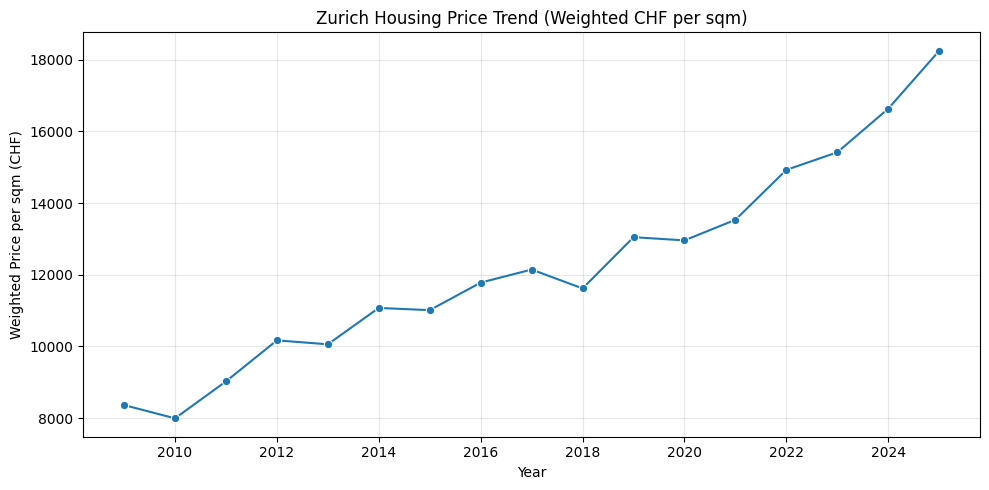

,year,weighted_price_per_sqm_chf
0,2009,8362.844417
1,2010,7992.421847
2,2011,9023.297389
3,2012,10168.775036
4,2013,10059.070783
5,2014,11074.154630
6,2015,11012.143078
7,2016,11780.965760
8,2017,12145.545333
9,2018,11618.176471


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load analysis-ready dataset
df = pd.read_csv("data/zurich_housing_analysis_ready.csv")

# Validate core numeric fields
df["year"] = pd.to_numeric(df["year"], errors="coerce")
df["price_per_sqm_chf"] = pd.to_numeric(df["price_per_sqm_chf"], errors="coerce")
df["num_transactions"] = pd.to_numeric(df["num_transactions"], errors="coerce")

# Keep valid rows for trend calculation
trend_df = df.dropna(subset=["year", "price_per_sqm_chf", "num_transactions"]).copy()
trend_df = trend_df[trend_df["num_transactions"] > 0]

# Compute transaction-weighted annual price per sqm
yearly_trend = (
    trend_df.groupby("year", as_index=False)
    .apply(
        lambda x: pd.Series(
            {
                "weighted_price_per_sqm_chf": (
                    (x["price_per_sqm_chf"] * x["num_transactions"]).sum()
                    / x["num_transactions"].sum()
                )
            }
        )
    )
)

# Plot trend
plt.figure(figsize=(10, 5))
sns.lineplot(
    data=yearly_trend,
    x="year",
    y="weighted_price_per_sqm_chf",
    marker="o"
)
plt.title("Zurich Housing Price Trend (Weighted CHF per sqm)")
plt.xlabel("Year")
plt.ylabel("Weighted Price per sqm (CHF)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Show summary table
yearly_trend


## District Price Ranking (Transaction-Weighted)

This section compares Zurich districts using transaction-weighted average price per sqm across the full time window (2009–2025).  
A weighted metric is used to avoid overemphasizing low-activity segments.


C:\Users\alrub\AppData\Local\Temp\ipykernel_24364\3930155606.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


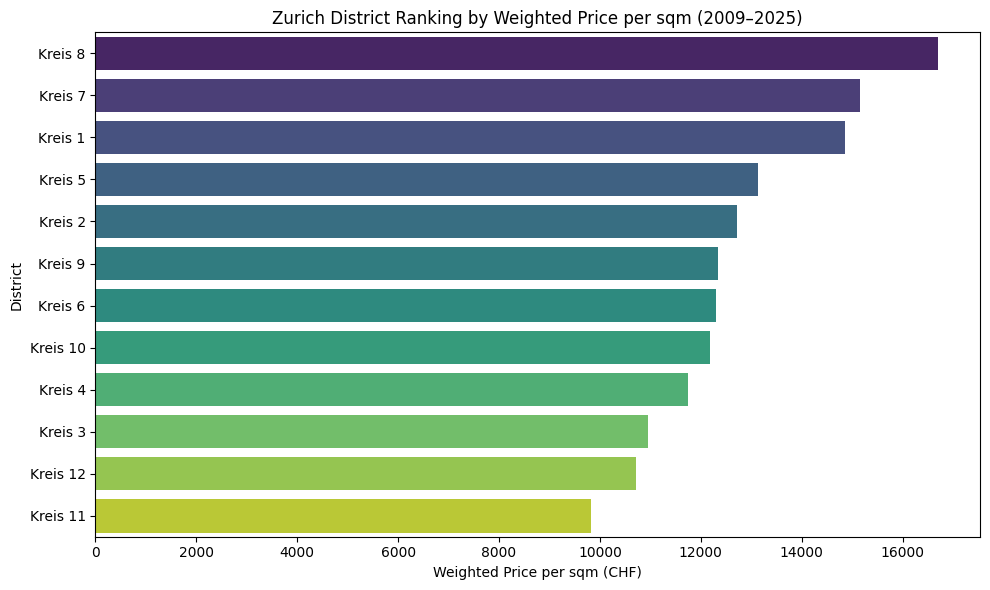

,area_name,weighted_price_per_sqm_chf
10,Kreis 8,16698.565574
9,Kreis 7,15163.612882
0,Kreis 1,14850.000000
7,Kreis 5,13127.266138
4,Kreis 2,12710.241223
11,Kreis 9,12346.007937
8,Kreis 6,12294.939433
1,Kreis 10,12185.084139
6,Kreis 4,11744.759184
5,Kreis 3,10957.441520


In [11]:
district_df = df[df["area_level"] == "district"].copy()

district_rank = (
    district_df.groupby("area_name")
    .apply(lambda x: (x["price_per_sqm_chf"] * x["num_transactions"]).sum() / x["num_transactions"].sum())
    .reset_index(name="weighted_price_per_sqm_chf")
    .sort_values("weighted_price_per_sqm_chf", ascending=False)
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=district_rank,
    y="area_name",
    x="weighted_price_per_sqm_chf",
    palette="viridis"
)
plt.title("Zurich District Ranking by Weighted Price per sqm (2009–2025)")
plt.xlabel("Weighted Price per sqm (CHF)")
plt.ylabel("District")
plt.tight_layout()
plt.show()

district_rank.head(12)


## District Momentum (YoY Change: 2025 vs 2024)

We measure short-term momentum by computing year-over-year average price changes at district level.


C:\Users\alrub\AppData\Local\Temp\ipykernel_24364\798755732.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


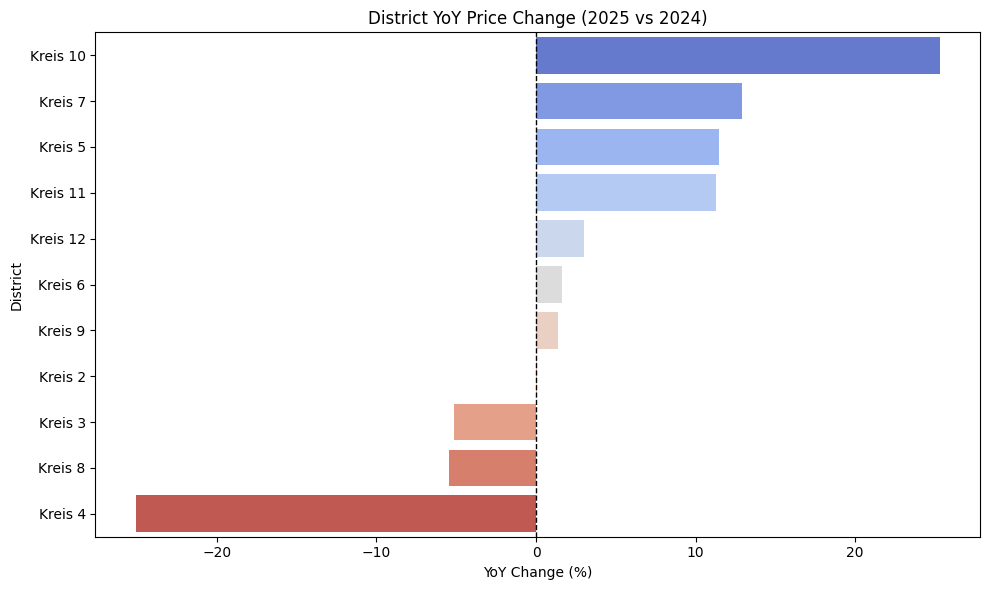

year,yoy_2025_pct
area_name,
Kreis 10,25.298967
Kreis 7,12.907836
Kreis 5,11.439602
Kreis 11,11.285163
Kreis 12,2.995221
Kreis 6,1.615768
Kreis 9,1.406170
Kreis 2,0.075501
Kreis 3,-5.107663


In [12]:
district_yoy = (
    district_df[district_df["year"].isin([2024, 2025])]
    .pivot_table(index="area_name", columns="year", values="price_per_sqm_chf", aggfunc="mean")
    .dropna()
)
district_yoy["yoy_2025_pct"] = ((district_yoy[2025] - district_yoy[2024]) / district_yoy[2024]) * 100
district_yoy = district_yoy.sort_values("yoy_2025_pct", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=district_yoy.reset_index(),
    x="yoy_2025_pct",
    y="area_name",
    palette="coolwarm"
)
plt.title("District YoY Price Change (2025 vs 2024)")
plt.xlabel("YoY Change (%)")
plt.ylabel("District")
plt.axvline(0, color="black", linestyle="--", linewidth=1)
plt.tight_layout()
plt.show()

district_yoy[["yoy_2025_pct"]]


## Room Segment Analysis (Latest Year)

This section compares room segments in the latest available year to identify which segment is currently priced highest.


C:\Users\alrub\AppData\Local\Temp\ipykernel_24364\2389132102.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


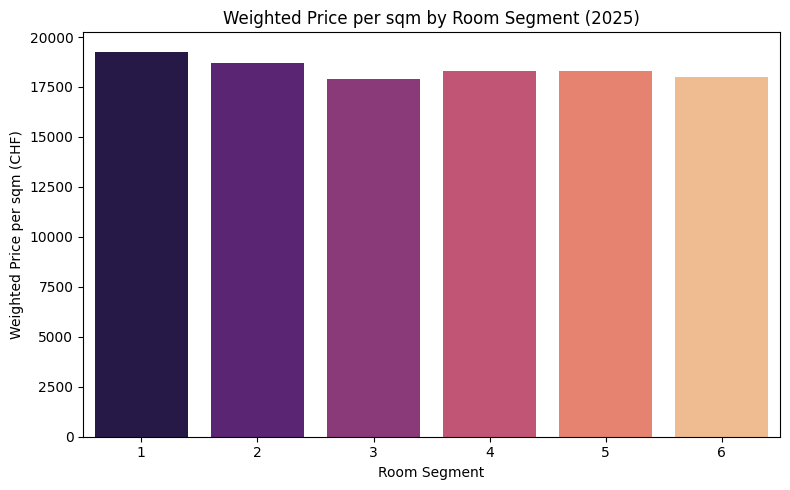

,year,rooms_num,weighted_price_per_sqm_chf
93,2025,1,19270.016667
94,2025,2,18723.496815
97,2025,5,18291.450000
96,2025,4,18279.809045
98,2025,6,17980.000000
95,2025,3,17920.328018


In [13]:
room_latest = (
    df.groupby(["year", "rooms_num"])
    .apply(lambda x: (x["price_per_sqm_chf"] * x["num_transactions"]).sum() / x["num_transactions"].sum())
    .reset_index(name="weighted_price_per_sqm_chf")
)

latest_year = int(room_latest["year"].max())
room_latest_year = room_latest[room_latest["year"] == latest_year].sort_values(
    "weighted_price_per_sqm_chf", ascending=False
)

plt.figure(figsize=(8, 5))
sns.barplot(
    data=room_latest_year,
    x="rooms_num",
    y="weighted_price_per_sqm_chf",
    palette="magma"
)
plt.title(f"Weighted Price per sqm by Room Segment ({latest_year})")
plt.xlabel("Room Segment")
plt.ylabel("Weighted Price per sqm (CHF)")
plt.tight_layout()
plt.show()

room_latest_year


## Market Pressure Index

We define a simple pressure indicator to detect districts with both:
- strong recent price growth (YoY),
- low transaction volume (potential supply pressure).

This is a heuristic index for portfolio storytelling, not a causal metric.


C:\Users\alrub\AppData\Local\Temp\ipykernel_24364\2483275718.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


<Axes: xlabel='pressure_index', ylabel='area_name'>

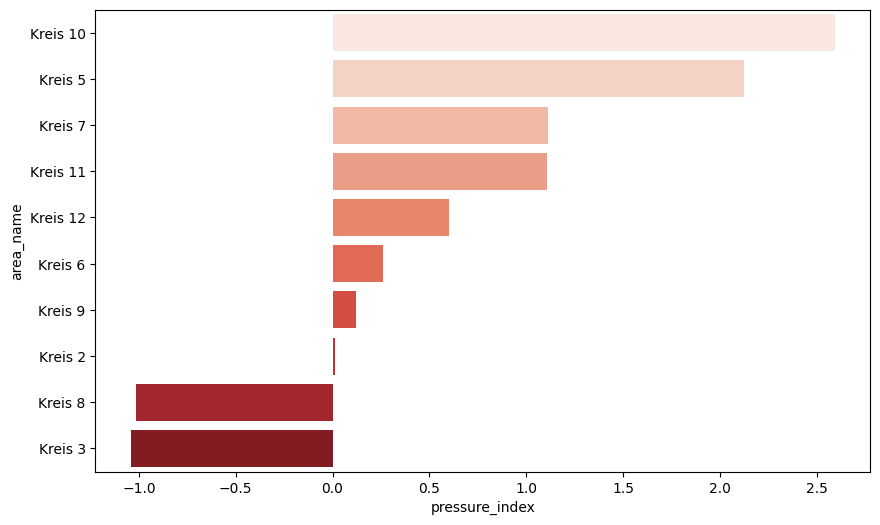

In [17]:
district_2025 = district_df[district_df["year"] == 2025].groupby("area_name", as_index=False).agg(
    tx_2025=("num_transactions", "sum"),
    avg_price_2025=("price_per_sqm_chf", "mean")
)

pressure = district_2025.merge(
    district_yoy[["yoy_2025_pct"]].reset_index(),
    on="area_name",
    how="inner"
)

pressure["pressure_index"] = pressure["yoy_2025_pct"] / (pressure["tx_2025"] ** 0.5)
pressure = pressure.sort_values("pressure_index", ascending=False)

pressure.head(10)
plt.figure(figsize=(10, 6))
sns.barplot(
    data=pressure.head(10),
    x="pressure_index",
    y="area_name",
    palette="Reds"
)

## Executive Summary (Auto-Generated KPIs)

This section provides a concise business summary suitable for recruiters and hiring managers.


In [18]:
yearly_trend = (
    df.groupby("year")
    .apply(lambda x: (x["price_per_sqm_chf"] * x["num_transactions"]).sum() / x["num_transactions"].sum())
    .reset_index(name="weighted_price_per_sqm_chf")
    .sort_values("year")
)

start_year = int(yearly_trend["year"].min())
end_year = int(yearly_trend["year"].max())
start_price = yearly_trend.iloc[0]["weighted_price_per_sqm_chf"]
end_price = yearly_trend.iloc[-1]["weighted_price_per_sqm_chf"]
years = end_year - start_year
cagr = ((end_price / start_price) ** (1 / years) - 1) * 100

top_district = district_rank.iloc[0]
top_momentum = district_yoy.reset_index().iloc[0]
worst_momentum = district_yoy.reset_index().iloc[-1]

print("=== Zurich Housing Market: Key Findings ===")
print(f"Period analyzed: {start_year}–{end_year}")
print(f"Weighted city price per sqm: CHF {start_price:,.0f} -> CHF {end_price:,.0f}")
print(f"Estimated CAGR: {cagr:.2f}% per year")
print(f"Most expensive district (weighted): {top_district['area_name']} (CHF {top_district['weighted_price_per_sqm_chf']:,.0f}/sqm)")
print(f"Top YoY district in 2025: {top_momentum['area_name']} ({top_momentum['yoy_2025_pct']:.2f}%)")
print(f"Weakest YoY district in 2025: {worst_momentum['area_name']} ({worst_momentum['yoy_2025_pct']:.2f}%)")


=== Zurich Housing Market: Key Findings ===
Period analyzed: 2009–2025
Weighted city price per sqm: CHF 8,363 -> CHF 18,254
Estimated CAGR: 5.00% per year
Most expensive district (weighted): Kreis 8 (CHF 16,699/sqm)
Top YoY district in 2025: Kreis 10 (25.30%)
Weakest YoY district in 2025: Kreis 4 (-25.09%)
